In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'<<{_str}>>:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 63.5 MB/s eta 0:00:00


In [3]:
import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim

import lightning as L
from lightning.pytorch.accelerators import accelerator
from torchmetrics import functional as FM
from torchinfo import summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]

torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## Image Datasets

In [4]:
from torchvision.datasets import MNIST, FashionMNIST, CIFAR10, CIFAR100
from torchvision.transforms import v2
from torch.utils.data import DataLoader

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size=1024 ####

download_root = './MNIST'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)
trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)
valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)

download_root = './CIFAR10'
cifar10_train = CIFAR10(download_root, transform=transform, train=True, download=True)
cifar10_test = CIFAR10(download_root, transform=transform, train=False, download=True)
c10TrainDataLoader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True,num_workers=4)
c10ValDataLoader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False,num_workers=4)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.71MB/s]
100%|██████████| 170M/170M [00:14<00:00, 12.0MB/s]


In [5]:
pst(trainDataLoader.dataset.data)     # MNIST image
pst(c10TrainDataLoader.dataset.data)  # CIFAR10 image

[] Shapetorch.Size([60000, 28, 28]), <class 'torch.Tensor'>
[] Shape(50000, 32, 32, 3), <class 'numpy.ndarray'>


## Base Model : MNIST

In [6]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [7]:
class Model(Wrap_10):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10))

    def forward(self, x):
        return self.layers(x)

model = Model()
summary(model, input_size=(8, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 256]                  200,960
│    └─BatchNorm1d: 2-3                  [8, 256]                  512
│    └─ReLU: 2-4                         [8, 256]                  --
│    └─Dropout: 2-5                      [8, 256]                  --
│    └─Linear: 2-6                       [8, 10]                   2,570
Total params: 204,042
Trainable params: 204,042
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.03
Forward/backward pass size (MB): 0.03
Params size (MB): 0.82
Estimated Total Size (MB): 0.87

In [8]:
%%time
model = Model()

name = 'base'
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=15, logger=logger,enable_model_summary=False)# overfit_batches=0.3)
trainer.fit(model, trainDataLoader, valDataLoader)
#Wall time: 57.8 s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


CPU times: user 9.68 s, sys: 4.05 s, total: 13.7 s
Wall time: 1min 3s


In [10]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

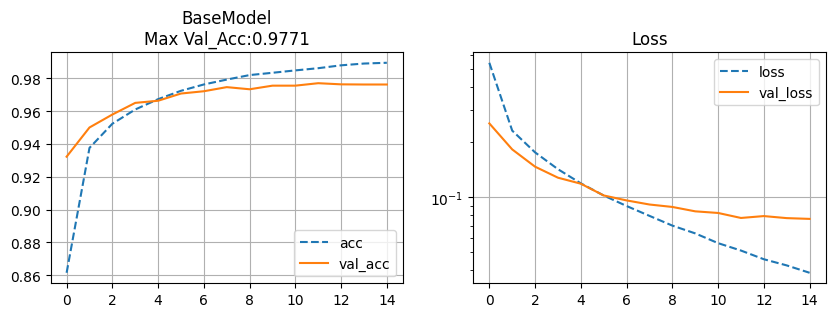

In [11]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = "BaseModel"
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

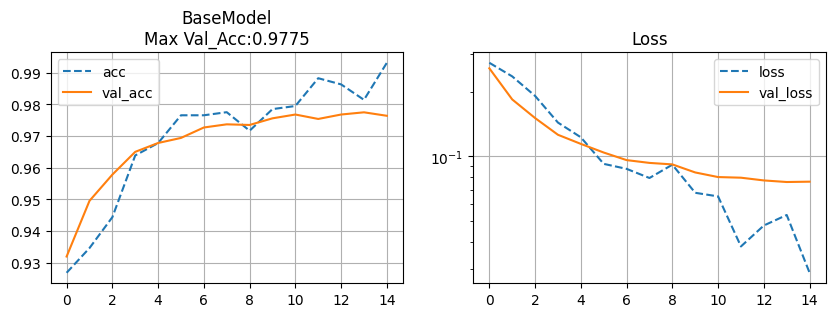

In [ ]:
!STOP

/bin/bash: line 1: STOP: command not found


## 실습 : CIFAR-10

실습
Sample code에서 시작하여 모델을 개선하세요
최종모델 code와 학습과정을 제출하세요.

**Step 1** :  
input dataset 을 CIFAR-10 으로 바꾸고  
기본 모델과, BatchNormalization Layer를 추가한
모델의 성능변화를 확인 하세요.  
Input data의 shape에 주의    
**Step 2** :  
모델 개선 : Layer추가 및 기타 개선  
Dropout등 도 추가, val_acc가 최고인 모델을 만들어 보세요.  
성능개선에 영향를 주는 요인 파악  
Epoch = 15, batch_size = 1024 유지   
**Step 3** :  
목표 : val_acc 65%이상  
Epoch = 15, batch_size = 1024 유지  


실습 코드와 결과를 아래에 저장 하세요.

## 실습결과 예시

##### 결과 : Step 1,2  

In [12]:
### input dataset을 CIFA-10으로 바꿔봅니다.

# 데이터 준비
x_train, y_train = next(iter(c10TrainDataLoader))
x_test, y_test = next(iter(c10ValDataLoader))
ps(x_train),ps(y_train)

[] Shapetorch.Size([1024, 3, 32, 32])
[] Shapetorch.Size([1024])


(None, None)

In [13]:
class Model(Wrap_10):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 128), ##
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

model = Model()
summary(model, input_size=(8, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 3072]                 --
│    └─Linear: 2-2                       [8, 128]                  393,344
│    └─BatchNorm1d: 2-3                  [8, 128]                  256
│    └─ReLU: 2-4                         [8, 128]                  --
│    └─Dropout: 2-5                      [8, 128]                  --
│    └─Linear: 2-6                       [8, 10]                   1,290
Total params: 394,890
Trainable params: 394,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.16
Input size (MB): 0.10
Forward/backward pass size (MB): 0.02
Params size (MB): 1.58
Estimated Total Size (MB): 1.69

In [14]:
%%time
model = Model()

name = 'ImprovedModel'
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=3, logger=logger,enable_model_summary=False,
                    limit_train_batches=0.1, limit_val_batches=0.1  #####
                    )
trainer.fit(model, c10TrainDataLoader, c10ValDataLoader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


CPU times: user 645 ms, sys: 702 ms, total: 1.35 s
Wall time: 3.74 s


##### 결과 : Step 3

In [15]:
class Model(Wrap_10):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(3*32*32, 256), ##
            nn.BatchNorm1d(256),
            nn.ReLU(),

####

            nn.Dropout(0.4),
            nn.Linear(256, 10))

    def forward(self, x):
        x = self.layers(x)
        return x

model = Model()
summary(model, input_size=(8, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 3072]                 --
│    └─Dropout: 2-2                      [8, 3072]                 --
│    └─Linear: 2-3                       [8, 256]                  786,688
│    └─BatchNorm1d: 2-4                  [8, 256]                  512
│    └─ReLU: 2-5                         [8, 256]                  --
│    └─Dropout: 2-6                      [8, 256]                  --
│    └─Linear: 2-7                       [8, 10]                   2,570
Total params: 789,770
Trainable params: 789,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.32
Input size (MB): 0.10
Forward/backward pass size (MB): 0.03
Params size (MB): 3.16
Estimated Total Size (MB): 3.29

In [ ]:
%%time
model = Model()

name = 'ImprovedModel'
logger = L.pytorch.loggers.CSVLogger("logs", name=name)
trainer = L.Trainer(max_epochs=15, logger=logger,enable_model_summary=False)#overfit_batches=0.3)
trainer.fit(model, c10TrainDataLoader, c10ValDataLoader)

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['val_acc'], label='val_acc')
plt.plot(h1['acc'],'--', label='acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['val_loss'], label='val_loss')
plt.plot(h1['loss'],'--', label='loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

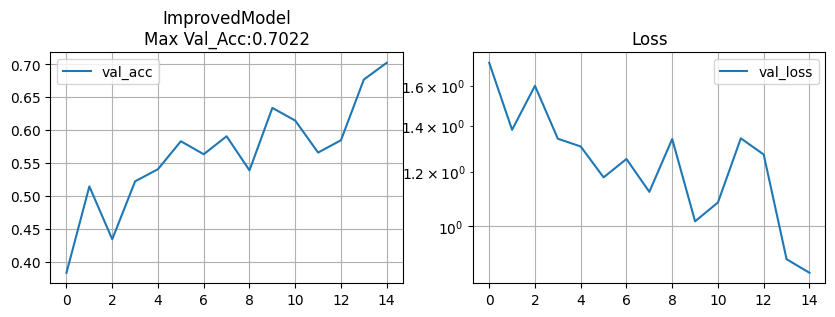